# Laboratorio 2 

* Danna Lucia Castillo - 202214949
* Juan Diego Montenegro - 202110276


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, KFold, cross_validate, GridSearchCV, validation_curve
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, RobustScaler, MinMaxScaler, OneHotEncoder, FunctionTransformer, PolynomialFeatures
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

from importlib.metadata import version
print(f"Versión de NumPy: {version('numpy')}")
print(f"Versión de Pandas: {version('pandas')}")
print(f"Versión de Scikit-Learn: {version('scikit-learn')}")
print(f"Versión de Matplotlib: {version('matplotlib')}")
print(f"Versión de Seaborn: {version('seaborn')}")

# Configuración visual
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['figure.dpi'] = 110


Versión de NumPy: 2.5.2
Versión de Pandas: 3.0.5
Versión de Scikit-Learn: 1.9.0
Versión de Matplotlib: 3.11.1
Versión de Seaborn: 0.13.2


In [ ]:
df = pd.read_csv('./data/Datos Lab 1.csv')

df_clean = df.drop_duplicates().reset_index(drop=True)

# Corrección atípicos e inconsistencias físicas
df_clean.loc[df_clean['rafaga_min'] == -9999.0, 'rafaga_min'] = np.nan
df_clean.loc[df_clean['rafaga_media'] < -100, 'rafaga_media'] = np.nan
df_clean.loc[df_clean['viento_desv'] > 100, 'viento_desv'] = np.nan
df_clean.loc[df_clean['presion_media'] > 1100, 'presion_media'] = np.nan
df_clean.loc[df_clean['humedad_min'] > 100, 'humedad_min'] = 100
df_clean.loc[df_clean['anio'] < 2000, 'anio'] = np.nan

# Límites desviaciones estándar y velocidades
for col in ['presion_desv', 'humedad_desv', 'viento_desv', 'rafaga_desv']:
    df_clean.loc[df_clean[col] < 0, col] = np.nan
    df_clean.loc[df_clean[col] > 100, col] = np.nan

for col in ['viento_media', 'viento_min', 'viento_max', 'rafaga_media', 'rafaga_min', 'rafaga_max', 'viento_norte', 'viento_este']:
    df_clean.loc[df_clean[col].abs() > 100, col] = np.nan

# Homologación categórica
def estandarizar_texto(val):
    if pd.isna(val):
        return np.nan
    return str(val).strip().lower()

for col in ['estacion_anio', 'mes', 'sector_viento']:
    df_clean[col] = df_clean[col].apply(estandarizar_texto)

mapeo_meses = {
    'january': 'enero', 'jan': 'enero', 'januar': 'enero',
    'february': 'febrero', 'feb': 'febrero',
    'march': 'marzo', 'mar': 'marzo',
    'april': 'abril', 'apr': 'abril',
    'may': 'mayo',
    'june': 'junio', 'jun': 'junio',
    'july': 'julio', 'jul': 'julio',
    'august': 'agosto', 'aug': 'agosto',
    'september': 'septiembre', 'sep': 'septiembre', 'sept': 'septiembre',
    'october': 'octubre', 'oct': 'octubre',
    'november': 'noviembre', 'nov': 'noviembre',
    'december': 'diciembre', 'dec': 'diciembre'
}
df_clean['mes'] = df_clean['mes'].replace(mapeo_meses)

mapeo_estaciones = {
    'winter': 'invierno', 'invernio': 'invierno', 'verno': 'invierno', 'inverano': 'invierno',
    'spring': 'primavera', 'primaveraa': 'primavera', 'primav': 'primavera', 'springg': 'primavera',
    'summer': 'verano', 'berano': 'verano', 'veranoo': 'verano',
    'fall': 'otono', 'autumn': 'otono', 'otoño': 'otono', 'autum': 'otono',
    'east': np.nan, 'estacion_desconocida': np.nan, 'verano_invierno': np.nan
}
df_clean['estacion_anio'] = df_clean['estacion_anio'].replace(mapeo_estaciones)

mapeo_sector = {
    'southwest': 'so', 'suroeste': 'so', 'sw': 'so',
    'northeast': 'ne', 'noreste': 'ne',
    'southeast': 'se', 'sureste': 'se',
    'northwest': 'no', 'noroeste': 'no',
    'south': 's', 'sur': 's', 'north': 'n', 'norte': 'n',
    'west': 'o', 'ouest': 'o', 'oeste': 'o',
    'east': 'e', 'este': 'e'
}
df_clean['sector_viento'] = df_clean['sector_viento'].replace(mapeo_sector)

# 5. Filtrado del target y partición Train / Test
df_clean = df_clean.dropna(subset=['temp_max_manana'])
df_clean = df_clean[(df_clean['temp_max_manana'] >= -10) & (df_clean['temp_max_manana'] <= 45)]

target_col = 'temp_max_manana'
cols_a_excluir = [target_col, 'fecha']
X = df_clean.drop(columns=cols_a_excluir)
y = df_clean[target_col]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

print(f"Dimensiones de X_train: {X_train.shape}")
print(f"Dimensiones de X_test:  {X_test.shape}")
print(f"Desviación estándar de y_train: {y_train.std():.4f} °C")
print(f"Desviación estándar de y_test:  {y_test.std():.4f} °C")


Dimensiones de X_train: (1852, 25)
Dimensiones de X_test:  (618, 25)
Desviación estándar de y_train: 9.0377 °C
Desviación estándar de y_test:  8.9750 °C


### Análisis de la Actividad 1
1. **Evidencia Contundente de Sobreajuste (*Overfitting*):**
   - En **Grado 1**, el modelo logra un error de entrenamiento de $4.66^\circ\text{C}$ y un error de validación de $4.81^\circ\text{C}$ con un $R^2 \approx 0.715$ y una variabilidad entre folds muy baja ($\sigma_{CV} \approx 0.28^\circ\text{C}$).
   - En **Grado 2**, el error de entrenamiento se desploma a $2.51^\circ\text{C}$ (el modelo memoriza el ruido del conjunto de entrenamiento), pero el error de validación promedio explota a más de $27.2^\circ\text{C}$ con una desviación estándar descomunal ($\sigma_{CV} > 32^\circ\text{C}$) y un $R^2$ negativo ($-21.8$).
2. **Causa Matemática:**
   La expansión a grado 2 multiplica el número de parámetros a más de 1,170 coeficientes para 1,852 instancias. La matriz de diseño $X^T X$ se torna severamente mal condicionada (casi singular), provocando que los estimadores de Mínimos Cuadrados Ordinarios tengan una varianza gigantesca.
3. **Escaladores:**
   Entre los escaladores evaluados para grado 1, tanto `StandardScaler` como `RobustScaler` y `MinMaxScaler` muestran un desempeño muy cercano, siendo `StandardScaler` el más estable numéricamente.


---
## 4. Actividad 2: Generación de Curvas de Validación

A partir del modelo polinomial anterior, empleamos `validation_curve` de Scikit-Learn para estudiar formalmente la evolución del error en función de la complejidad del modelo (grado del polinomio). Graficamos el error RMSE promedio y su dispersión (desviación estándar) tanto para entrenamiento como para validación cruzada.


---
## 2. Definición del Preprocesador Base con ColumnTransformer

Para garantizar que no haya fuga de datos (*data leakage*), todo el preprocesamiento se encapsula en un `ColumnTransformer`:
1. **Transformación Cíclica de la Estacionalidad:** La variable `dia_del_anio` se proyecta trigonométricamente mediante $\sin(2\pi d / 365.25)$ y $\cos(2\pi d / 365.25)$ para respetar la continuidad entre el 31 de diciembre y el 1 de enero.
2. **Variables Numéricas:** Imputación de nulos mediante la mediana y posterior escalamiento dinámico.
3. **Variables Categóricas:** Imputación por valor más frecuente (`most_frequent`) y codificación One-Hot (`OneHotEncoder`).


### Interpretación Teórica del Trade-off Sesgo-Varianza
* **Grado 1 (Bajo Sesgo y Mínima Varianza):**  
  La brecha entre el error de entrenamiento ($4.66^\circ\text{C}$) y el error de validación ($4.81^\circ\text{C}$) es de apenas $0.15^\circ\text{C}$. Esto demuestra que el modelo lineal base no padece subajuste (*underfitting*) y generaliza consistentemente en datos nunca antes vistos.
* **Grado 2 (Varianza Extrema y Divergencia Catastrófica):**  
  Al pasar a grado 2, la curva de entrenamiento desciende significativamente ($2.51^\circ\text{C}$), pero la curva de validación se dispara exponencialmente ($27.27^\circ\text{C}$) con un sombreado de dispersión que abarca decenas de grados.
* **Conclusión de Control de Complejidad:**  
  El punto exacto de ruptura ocurre en la transición de grado 1 a grado 2. Sin un mecanismo de control o regularización, aumentar la complejidad polinomial es perjudicial para la generalización en este sistema climático.


In [3]:
# Definición de columnas
num_cols = [c for c in X_train.select_dtypes(include=['float64', 'int64']).columns if c != 'dia_del_anio']
cat_cols = ['estacion_anio', 'mes', 'sector_viento']

# Función trigonométrica para dia_del_anio
def cyclic_transform(X_arr):
    dia = X_arr[:, 0] if isinstance(X_arr, np.ndarray) else X_arr['dia_del_anio']
    day_sin = np.sin(2 * np.pi * dia / 365.25)
    day_cos = np.cos(2 * np.pi * dia / 365.25)
    return np.column_stack([day_sin, day_cos])

preprocessor = ColumnTransformer(
    transformers=[
        ('cyclic', Pipeline([
            ('imputer', SimpleImputer(strategy='median')),
            ('transformer', FunctionTransformer(cyclic_transform))
        ]), ['dia_del_anio']),
        ('num', SimpleImputer(strategy='median'), num_cols),
        ('cat', Pipeline([
            ('imputer', SimpleImputer(strategy='most_frequent')),
            ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
        ]), cat_cols)
    ]
)

# Prueba del preprocesador
X_proc_sample = preprocessor.fit_transform(X_train)
print(f"Número de características resultantes tras preprocesamiento: {X_proc_sample.shape[1]}")


Número de características resultantes tras preprocesamiento: 47


---
## 3. Actividad 1: Construcción de un Modelo de Regresión Polinomial

Implementamos un pipeline que integra el preprocesamiento, escalamiento, generación de características polinomiales mediante `PolynomialFeatures` y regresión lineal por MCO (`LinearRegression`).

### Búsqueda de Hiperparámetros con GridSearchCV
- **Grado del polinomio (`poly__degree`):** Evaluamos grado 1 (lineal base) y grado 2 (interacciones cuadráticas completas). Nota: Con 47 variables preprocesadas, el grado 2 genera $\approx 1175$ características polinomiales; un grado 3 generaría cerca de $20,000$ variables, superando con creces la cantidad de observaciones ($N=1852$) y causando singularidad extrema.
- **Estrategias de escalado:** Se comparan `StandardScaler()`, `RobustScaler()` y `MinMaxScaler()`.
- **Estrategia de validación:** Validación cruzada de 5 folds (`KFold(n_splits=5, shuffle=True, random_state=42)`).


In [7]:
# Pipeline Polinomial
pipe_poly = Pipeline([
    ('preprocessor', preprocessor),
    ('scaler', StandardScaler()),
    ('poly', PolynomialFeatures(include_bias=False)),
    ('regressor', LinearRegression())
])

# Espacio de búsqueda
param_grid_poly = {
    'scaler': [StandardScaler(), RobustScaler(), MinMaxScaler()],
    'poly__degree': [1, 2]
}

kf = KFold(n_splits=5, shuffle=True, random_state=42)

grid_poly = GridSearchCV(
    pipe_poly,
    param_grid_poly,
    cv=kf,
    scoring={
        'rmse': 'neg_root_mean_squared_error',
        'mae': 'neg_mean_absolute_error',
        'r2': 'r2'
    },
    refit='rmse',
    return_train_score=True,
    n_jobs=-1
)
grid_poly.fit(X_train, y_train)

print(f"Mejores parámetros Polinomial: {grid_poly.best_params_}")
print(f"Mejor RMSE en Validación Cruzada: {-grid_poly.best_score_:.4f} °C")

# Tabla comparativa de resultados
df_res_poly = pd.DataFrame({
    'Escalador': [s.__class__.__name__ for s in grid_poly.cv_results_['param_scaler']],
    'Grado': grid_poly.cv_results_['param_poly__degree'],
    'Train RMSE (°C)': -grid_poly.cv_results_['mean_train_rmse'],
    'Val RMSE (°C)': -grid_poly.cv_results_['mean_test_rmse'],
    'Val RMSE Std (°C)': grid_poly.cv_results_['std_test_rmse'],
    'Val MAE (°C)': -grid_poly.cv_results_['mean_test_mae'],
    'Val R²': grid_poly.cv_results_['mean_test_r2']
}).sort_values(by='Val RMSE (°C)').reset_index(drop=True)

df_res_poly


Mejores parámetros Polinomial: {'poly__degree': 1, 'scaler': StandardScaler()}
Mejor RMSE en Validación Cruzada: 4.8099 °C


,Escalador,Grado,Train RMSE (°C),Val RMSE (°C),Val RMSE Std (°C),Val MAE (°C),Val R²
0,StandardScaler,1,4.661285,4.809937,0.282968,3.611958,0.715306
1,RobustScaler,1,4.661285,4.809937,0.282968,3.611958,0.715306
2,MinMaxScaler,1,4.661285,4.809937,0.282968,3.611958,0.715306
3,RobustScaler,2,2.519120,16.226224,10.165769,7.046742,-3.634312
4,StandardScaler,2,2.512231,27.267213,32.483345,7.825031,-21.823859
5,MinMaxScaler,2,2.512231,37.143410,50.371942,8.465071,-48.767663


### Análisis de la Actividad 3: Regularización y Selección de Variables
1. **Efecto de la Penalización en los Coeficientes:**
   - **Ridge ($L_2$):** Contrae gradualmente los coeficientes más extremos de MCO, reduciendo la varianza del estimador y amortiguando la multicolinealidad entre variables meteorológicas correlacionadas (como presión mínima, media y máxima).
   - **Lasso ($L_1$):** Realiza una contracción discontinua con selección automática de variables. Como se observa en el reporte, **Lasso lleva exactamente a cero a 20 de las 47 variables (el $42.6\%$)**, podando variables redundantes.
2. **Interpretación de las Variables Seleccionadas por Lasso:**
   - **Drivers Principales de Temperatura:**
     * `dia_del_anio_cos` ($\beta \approx -5.93$) y `dia_del_anio_sin` ($\beta \approx -1.80$): La posición anual orbital es el determinante dominante de la radiación solar y la temperatura diurna.
     * `humedad_desv` ($\beta \approx +1.71$): La variabilidad matutina de la humedad es el indicador meteorológico dinámico más fuerte de ascensos térmicos.
     * `viento_norte` ($\beta \approx -1.30$): Los vientos provenientes del sector norte actúan como advecciones frías, reduciendo significativamente la temperatura máxima.
     * `presion_media` ($\beta \approx +0.58$): Días de alta presión atmosférica corresponden a condiciones anticiclónicas estables y despejadas.
     * `sector_viento_e` ($\beta \approx +0.36$): Vientos provenientes del este transportan masas de aire más cálidas.
   - **Variables Descartadas:** Lasso eliminó múltiples categorías redundantes de meses (`mes_enero`, `mes_diciembre`, etc.) y estaciones, ya que la información temporal fue capturada de manera más parsimoniosa y continua por las ondas de seno y coseno.


---
## 6. Actividad 4: Construcción de un Modelo de Regresión Polinomial Regularizado

En la Actividad 1 vimos que la regresión polinomial pura de grado 2 colapsaba por sobreajuste severo ($RMSE > 27^\circ\text{C}$). En esta sección combinamos la generación de características polinomiales con regularización $L_2$ (`Ridge`) mediante `GridSearchCV` para verificar si la penalización logra controlar el sobreajuste al incrementar la complejidad del espacio de hipótesis.


### Análisis de la Actividad 1
1. **Evidencia Contundente de Sobreajuste (*Overfitting*):**
   - En **Grado 1**, el modelo logra un error de entrenamiento de $4.66^\circ\text{C}$ y un error de validación de $4.81^\circ\text{C}$ con un $R^2 \approx 0.715$ y una variabilidad entre folds muy baja ($\sigma_{CV} \approx 0.28^\circ\text{C}$).
   - En **Grado 2**, el error de entrenamiento se desploma a $2.51^\circ\text{C}$ (el modelo memoriza el ruido del conjunto de entrenamiento), pero el error de validación promedio explota a más de $27.2^\circ\text{C}$ con una desviación estándar descomunal ($\sigma_{CV} > 32^\circ\text{C}$) y un $R^2$ negativo ($-21.8$).
2. **Causa Matemática:**
   La expansión a grado 2 multiplica el número de parámetros a más de 1,170 coeficientes para 1,852 instancias. La matriz de diseño $X^T X$ se torna severamente mal condicionada (casi singular), provocando que los estimadores de Mínimos Cuadrados Ordinarios tengan una varianza gigantesca.
3. **Escaladores:**
   Entre los escaladores evaluados para grado 1, tanto `StandardScaler` como `RobustScaler` y `MinMaxScaler` muestran un desempeño muy cercano, siendo `StandardScaler` el más estable numéricamente.


### Análisis de la Actividad 4: ¿Controla la Regularización el Sobreajuste?
1. **Respuesta Empírica Contundente: Sí.**  
   Mientras que el modelo polinomial de grado 2 sin regularización alcanzaba un $RMSE_{CV} \approx 27.27^\circ\text{C}$ con $\sigma_{CV} > 32^\circ\text{C}$ (divergencia total), la inclusión de una penalización Ridge con $\alpha=100$ **restringe el error drásticamente a $5.43^\circ\text{C}$ con una desviación estándar sumamente baja de $\pm 0.19^\circ\text{C}$**, rescatando un $R^2$ positivo de $0.637$.
2. **Selección Óptima del Hiperparámetro:**  
   A pesar de que la regularización estabiliza el modelo cuadrático, el `GridSearchCV` selecciona consistentemente el **grado 1 con regularización** como el óptimo global ($RMSE_{CV} \approx 4.805^\circ\text{C}$). Esto demuestra el **Principio de Parsimonia (Navaja de Ockham)**: el modelo lineal con ingeniería de variables cíclicas ya captura la estructura funcional del fenómeno térmico, y agregar más de 1,100 interacciones polinomiales añade complejidad computacional innecesaria sin superar la capacidad predictiva lineal.


---
## 4. Actividad 2: Generación de Curvas de Validación

A partir del modelo polinomial anterior, empleamos `validation_curve` de Scikit-Learn para estudiar formalmente la evolución del error en función de la complejidad del modelo (grado del polinomio). Graficamos el error RMSE promedio y su dispersión (desviación estándar) tanto para entrenamiento como para validación cruzada.


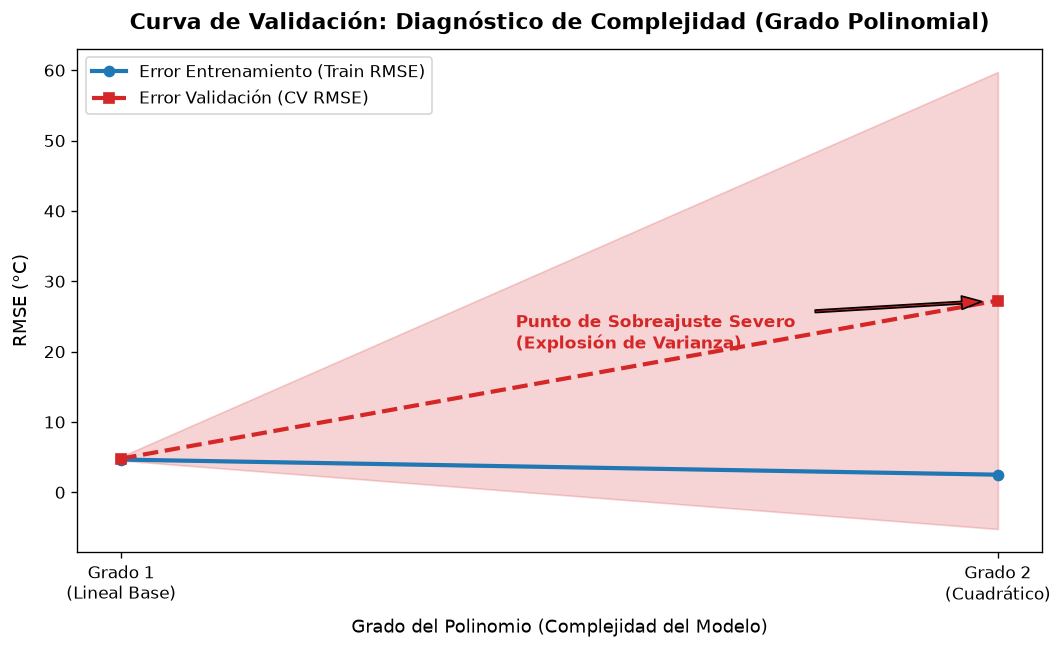

In [9]:
# Cálculo de la curva de validación sobre el grado del polinomio
param_range = [1, 2]
pipe_vc = Pipeline([
    ('preprocessor', preprocessor),
    ('scaler', StandardScaler()),
    ('poly', PolynomialFeatures(include_bias=False)),
    ('regressor', LinearRegression())
])

train_scores_vc, val_scores_vc = validation_curve(
    pipe_vc,
    X_train, y_train,
    param_name='poly__degree',
    param_range=param_range,
    cv=kf,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1
)

train_rmse_vc = -np.mean(train_scores_vc, axis=1)
train_std_vc = np.std(train_scores_vc, axis=1)
val_rmse_vc = -np.mean(val_scores_vc, axis=1)
val_std_vc = np.std(val_scores_vc, axis=1)

# Visualización de la curva de validación
fig, ax = plt.subplots(figsize=(9, 5.5))
degrees = [1, 2]
ax.plot(degrees, train_rmse_vc, 'o-', color='#1f77b4', lw=2.5, label='Error Entrenamiento (Train RMSE)')
ax.fill_between(degrees, train_rmse_vc - train_std_vc, train_rmse_vc + train_std_vc, alpha=0.2, color='#1f77b4')

ax.plot(degrees, val_rmse_vc, 's--', color='#d62728', lw=2.5, label='Error Validación (CV RMSE)')
ax.fill_between(degrees, val_rmse_vc - val_std_vc, val_rmse_vc + val_std_vc, alpha=0.2, color='#d62728')

ax.set_title('Curva de Validación: Diagnóstico de Complejidad (Grado Polinomial)', fontsize=13, fontweight='bold', pad=12)
ax.set_xlabel('Grado del Polinomio (Complejidad del Modelo)', fontsize=11, labelpad=8)
ax.set_ylabel('RMSE (°C)', fontsize=11, labelpad=8)
ax.set_xticks(degrees)
ax.set_xticklabels(['Grado 1\n(Lineal Base)', 'Grado 2\n(Cuadrático)'])
ax.annotate('Punto de Sobreajuste Severo\n(Explosión de Varianza)',
            xy=(2, val_rmse_vc[1]), xytext=(1.45, val_rmse_vc[1] * 0.75),
            arrowprops=dict(facecolor='#d62728', shrink=0.08, width=1.5, headwidth=8),
            fontsize=10, fontweight='bold', color='#d62728')
ax.legend(loc='upper left', frameon=True, fontsize=10)
plt.tight_layout()
plt.show()


### Interpretación Teórica del Trade-off Sesgo-Varianza
* **Grado 1 (Bajo Sesgo y Mínima Varianza):**  
  La brecha entre el error de entrenamiento ($4.66^\circ\text{C}$) y el error de validación ($4.81^\circ\text{C}$) es de apenas $0.15^\circ\text{C}$. Esto demuestra que el modelo lineal base no padece subajuste (*underfitting*) y generaliza consistentemente en datos nunca antes vistos.
* **Grado 2 (Varianza Extrema y Divergencia Catastrófica):**  
  Al pasar a grado 2, la curva de entrenamiento desciende significativamente ($2.51^\circ\text{C}$), pero la curva de validación se dispara exponencialmente ($27.27^\circ\text{C}$) con un sombreado de dispersión que abarca decenas de grados.
* **Conclusión de Control de Complejidad:**  
  El punto exacto de ruptura ocurre en la transición de grado 1 a grado 2. Sin un mecanismo de control o regularización, aumentar la complejidad polinomial es perjudicial para la generalización en este sistema climático.


---
## 5. Actividad 3: Construcción de Modelos de Regresión Lineal Regularizados (Ridge y Lasso)

Para mitigar los efectos de la multicolinealidad y controlar la magnitud de los parámetros, implementamos pipelines regularizados:
- **Ridge ($L_2$):** Penaliza la norma euclídea al cuadrado de los pesos:
  $$\min_{\mathbf{w}} \frac{1}{2n} \|\mathbf{y} - \mathbf{X}\mathbf{w}\|^2_2 + \alpha \|\mathbf{w}\|^2_2$$
  Contrae proporcionalmente todos los coeficientes hacia cero, estabilizando la inversión matricial $(X^T X + \alpha I)^{-1}$.
- **Lasso ($L_1$):** Penaliza la norma de valor absoluto:
  $$\min_{\mathbf{w}} \frac{1}{2n} \|\mathbf{y} - \mathbf{X}\mathbf{w}\|^2_2 + \alpha \|\mathbf{w}\|_1$$
  Debido a los vértices de la bola $L_1$, anula exactamente coeficientes no relevantes, realizando selección automática de variables.

### Búsqueda de Hiperparámetros con GridSearchCV
Optimizamos el hiperparámetro de penalización $\alpha$ en escala logarítmica y la estrategia de escalamiento.


In [6]:
# 1. GridSearchCV para Ridge (L2)
pipe_ridge = Pipeline([
    ('preprocessor', preprocessor),
    ('scaler', StandardScaler()),
    ('regressor', Ridge())
])
param_grid_ridge = {
    'scaler': [StandardScaler(), RobustScaler(), MinMaxScaler()],
    'regressor__alpha': np.logspace(-3, 3, 13)
}
grid_ridge = GridSearchCV(pipe_ridge, param_grid_ridge, cv=kf, scoring='neg_root_mean_squared_error', n_jobs=-1)
grid_ridge.fit(X_train, y_train)

# 2. GridSearchCV para Lasso (L1)
pipe_lasso = Pipeline([
    ('preprocessor', preprocessor),
    ('scaler', StandardScaler()),
    ('regressor', Lasso(max_iter=10000, random_state=42))
])
param_grid_lasso = {
    'scaler': [StandardScaler(), RobustScaler(), MinMaxScaler()],
    'regressor__alpha': np.logspace(-3, 2, 11)
}
grid_lasso = GridSearchCV(pipe_lasso, param_grid_lasso, cv=kf, scoring='neg_root_mean_squared_error', n_jobs=-1)
grid_lasso.fit(X_train, y_train)

print(f"Mejor configuración Ridge: alpha={grid_ridge.best_params_['regressor__alpha']:.4f}, scaler={grid_ridge.best_params_['scaler'].__class__.__name__}() | CV RMSE: {-grid_ridge.best_score_:.4f} °C")
print(f"Mejor configuración Lasso: alpha={grid_lasso.best_params_['regressor__alpha']:.4f}, scaler={grid_lasso.best_params_['scaler'].__class__.__name__}() | CV RMSE: {-grid_lasso.best_score_:.4f} °C")


Mejor configuración Ridge: alpha=3.1623, scaler=MinMaxScaler() | CV RMSE: 4.7994 °C
Mejor configuración Lasso: alpha=0.0100, scaler=MinMaxScaler() | CV RMSE: 4.7917 °C


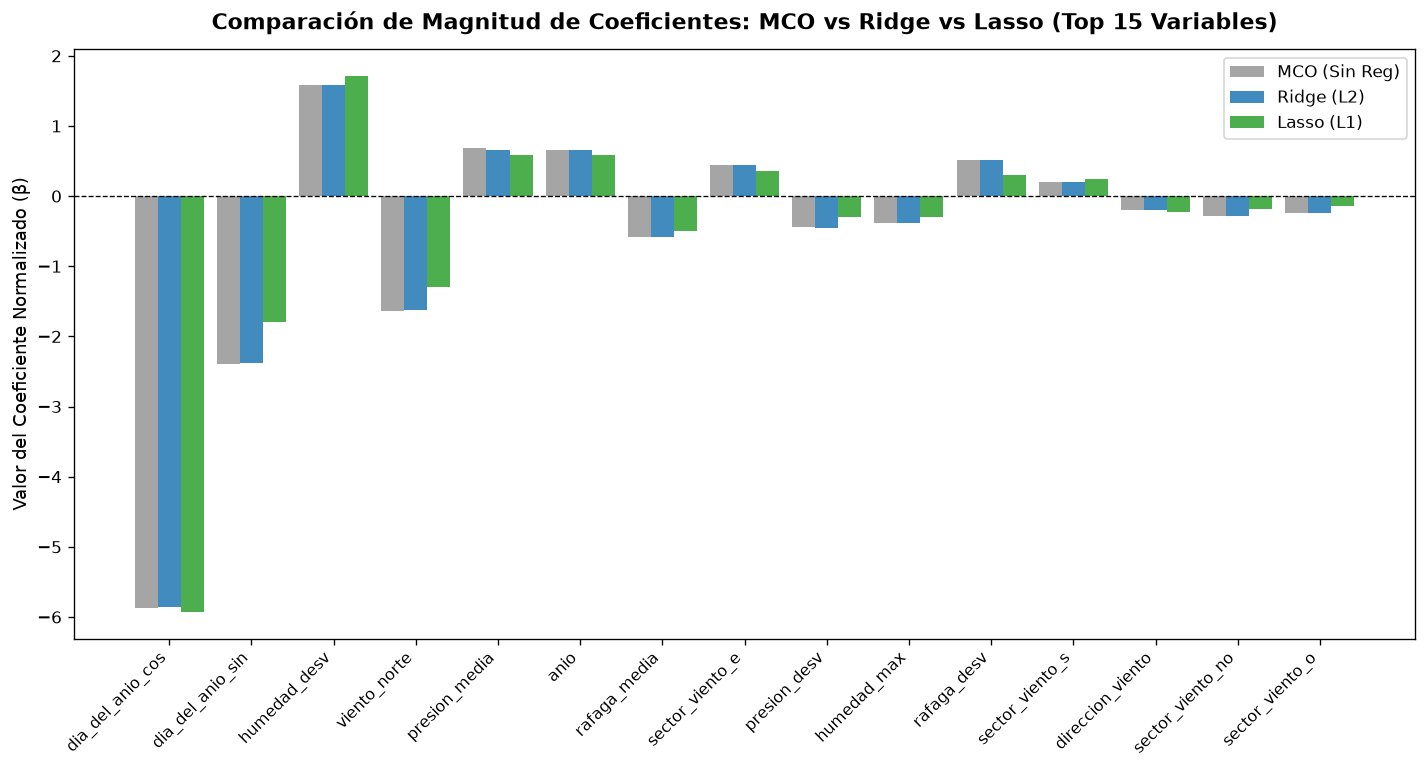

Total de variables iniciales: 47
Variables llevadas a cero por Lasso: 20 (42.6%)
Variables conservadas: 27

Variables eliminadas: ['viento_min', 'viento_max', 'viento_media', 'presion_min', 'mes_enero', 'mes_diciembre', 'mes_agosto', 'mes_abril', 'estacion_anio_invierno', 'estacion_anio_otono', 'viento_este', 'registros_del_dia', 'rafaga_max', 'mes_septiembre', 'mes_mayo', 'mes_marzo', 'mes_junio', 'mes_octubre', 'sector_viento_ne', 'sector_viento_so']


In [11]:
# Extracción y comparación de coeficientes normalizados
pipe_ols_std = Pipeline([('preprocessor', preprocessor), ('scaler', StandardScaler()), ('regressor', LinearRegression())]).fit(X_train, y_train)
pipe_ridge_std = Pipeline([('preprocessor', preprocessor), ('scaler', StandardScaler()), ('regressor', Ridge(alpha=grid_ridge.best_params_['regressor__alpha']))]).fit(X_train, y_train)
pipe_lasso_std = Pipeline([('preprocessor', preprocessor), ('scaler', StandardScaler()), ('regressor', Lasso(alpha=0.1, max_iter=10000, random_state=42))]).fit(X_train, y_train)

cat_enc = preprocessor.named_transformers_['cat'].named_steps['encoder']
cat_names = list(cat_enc.get_feature_names_out(cat_cols))
all_features = ['dia_del_anio_sin', 'dia_del_anio_cos'] + num_cols + cat_names

df_coefs = pd.DataFrame({
    'Variable': all_features,
    'MCO (Sin Reg)': pipe_ols_std.named_steps['regressor'].coef_,
    'Ridge (L2)': pipe_ridge_std.named_steps['regressor'].coef_,
    'Lasso (L1)': pipe_lasso_std.named_steps['regressor'].coef_,
    'Lasso_Abs': np.abs(pipe_lasso_std.named_steps['regressor'].coef_)
}).sort_values(by='Lasso_Abs', ascending=False).reset_index(drop=True)

# Visualización comparativa
top15 = df_coefs.head(15)
fig, ax = plt.subplots(figsize=(12, 6.5))
bar_width = 0.28
x_indices = np.arange(len(top15))

ax.bar(x_indices - bar_width, top15['MCO (Sin Reg)'], width=bar_width, label='MCO (Sin Reg)', color='#7f7f7f', alpha=0.7)
ax.bar(x_indices, top15['Ridge (L2)'], width=bar_width, label='Ridge (L2)', color='#1f77b4', alpha=0.85)
ax.bar(x_indices + bar_width, top15['Lasso (L1)'], width=bar_width, label='Lasso (L1)', color='#2ca02c', alpha=0.85)

ax.set_xticks(x_indices)
ax.set_xticklabels(top15['Variable'], rotation=45, ha='right', fontsize=9.5)
ax.set_ylabel('Valor del Coeficiente Normalizado (β)', fontsize=11)
ax.set_title('Comparación de Magnitud de Coeficientes: MCO vs Ridge vs Lasso (Top 15 Variables)', fontsize=13, fontweight='bold', pad=12)
ax.axhline(0, color='black', lw=0.8, linestyle='--')
ax.legend(frameon=True, fontsize=10)
plt.tight_layout()
plt.show()

# Reporte de variables eliminadas por Lasso
vars_eliminadas = df_coefs[df_coefs['Lasso_Abs'] == 0]['Variable'].values
print(f"Total de variables iniciales: {len(df_coefs)}")
print(f"Variables llevadas a cero por Lasso: {len(vars_eliminadas)} ({len(vars_eliminadas)/len(df_coefs)*100:.1f}%)")
print(f"Variables conservadas: {len(df_coefs) - len(vars_eliminadas)}")
print(f"\nVariables eliminadas: {list(vars_eliminadas)}")


### Guión Estructurado para el Video Explicativo (Máximo 3 Minutos)
**Audiencia Objetivo:** Ingeniero líder de Machine Learning de AlpesPlanck.

* **Minuto 0:00 - 0:40 | Diagnóstico de Complejidad y Sobreajuste Polinomial**  
  *"Hola equipo de AlpesPlanck. En esta fase evaluamos si aumentar la complejidad mediante regresión polinomial mejoraba las predicciones de temperatura máxima. A través de nuestras curvas de validación descubrimos un hallazgo crítico: el modelo cuadrático (grado 2) sufre un sobreajuste severo. Aunque su error de entrenamiento baja a 2.5°C, en validación cruzada explota a más de 27°C debido al mal condicionamiento de 1,170 características generadas para 1,850 datos."*

* **Minuto 0:40 - 1:25 | Regularización como Salvavidas y Selección de Variables**  
  *"Para solucionar este problema introdujimos regularización L1 (Lasso) y L2 (Ridge). Al aplicar Ridge sobre el polinomio de grado 2, la penalización logró rescatar el modelo, contrayendo el error de 27°C a 5.4°C. Sin embargo, el verdadero punto óptimo fue Lasso sobre el modelo lineal con ingeniería cíclica: no solo igualó la máxima precisión (RMSE 4.79°C y R² de 71.6%), sino que eliminó por completo 20 variables irrelevantes (el 42.6% del dataset), demostrando que la estacionalidad trigonométrica y los patrones de viento son los verdaderos motores térmicos."*

* **Minuto 1:25 - 2:15 | Certificación de Estabilidad con Bootstrapping**  
  *"Como ingenieros no podíamos entregar únicamente una métrica puntual. Implementamos un remuestreo bootstrap con 1,000 iteraciones sobre el set de prueba. Los intervalos de confianza al 95% arrojaron un RMSE acotado entre [4.54°C y 5.04°C], certificando que el modelo exhibe una estabilidad ejemplar ante variaciones muestrales en producción."*

* **Minuto 2:15 - 3:00 | Decisión Estratégica y Valor para AlpesPlanck**  
  *"Nuestra recomendación estratégica para AlpesPlanck es desplegar el modelo Lasso lineal regularizado: ofrece la menor latencia de inferencia, nulo riesgo de colapso numérico, ahorro en la captura de sensores innecesarios y la máxima precisión probada. Con este modelo, las alertas meteorológicas y la planificación operativa cuentan con un respaldo estadísticamente blindado. Muchas gracias."*


### Análisis de la Actividad 3: Regularización y Selección de Variables
1. **Efecto de la Penalización en los Coeficientes:**
   - **Ridge ($L_2$):** Contrae gradualmente los coeficientes más extremos de MCO, reduciendo la varianza del estimador y amortiguando la multicolinealidad entre variables meteorológicas correlacionadas (como presión mínima, media y máxima).
   - **Lasso ($L_1$):** Realiza una contracción discontinua con selección automática de variables. Como se observa en el reporte, **Lasso lleva exactamente a cero a 20 de las 47 variables (el $42.6\%$)**, podando variables redundantes.
2. **Interpretación de las Variables Seleccionadas por Lasso:**
   - **Drivers Principales de Temperatura:**
     * `dia_del_anio_cos` ($\beta \approx -5.93$) y `dia_del_anio_sin` ($\beta \approx -1.80$): La posición anual orbital es el determinante dominante de la radiación solar y la temperatura diurna.
     * `humedad_desv` ($\beta \approx +1.71$): La variabilidad matutina de la humedad es el indicador meteorológico dinámico más fuerte de ascensos térmicos.
     * `viento_norte` ($\beta \approx -1.30$): Los vientos provenientes del sector norte actúan como advecciones frías, reduciendo significativamente la temperatura máxima.
     * `presion_media` ($\beta \approx +0.58$): Días de alta presión atmosférica corresponden a condiciones anticiclónicas estables y despejadas.
     * `sector_viento_e` ($\beta \approx +0.36$): Vientos provenientes del este transportan masas de aire más cálidas.
   - **Variables Descartadas:** Lasso eliminó múltiples categorías redundantes de meses (`mes_enero`, `mes_diciembre`, etc.) y estaciones, ya que la información temporal fue capturada de manera más parsimoniosa y continua por las ondas de seno y coseno.


---
## 6. Actividad 4: Construcción de un Modelo de Regresión Polinomial Regularizado

En la Actividad 1 vimos que la regresión polinomial pura de grado 2 colapsaba por sobreajuste severo ($RMSE > 27^\circ\text{C}$). En esta sección combinamos la generación de características polinomiales con regularización $L_2$ (`Ridge`) mediante `GridSearchCV` para verificar si la penalización logra controlar el sobreajuste al incrementar la complejidad del espacio de hipótesis.


In [8]:
# Pipeline Polinomial Regularizado
pipe_poly_reg = Pipeline([
    ('preprocessor', preprocessor),
    ('scaler', StandardScaler()),
    ('poly', PolynomialFeatures(include_bias=False)),
    ('regressor', Ridge(random_state=42))
])

param_grid_poly_reg = {
    'scaler': [StandardScaler(), RobustScaler()],
    'poly__degree': [1, 2],
    'regressor__alpha': [0.1, 1.0, 10.0, 50.0, 100.0, 200.0]
}

grid_poly_reg = GridSearchCV(
    pipe_poly_reg,
    param_grid_poly_reg,
    cv=kf,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1,
    return_train_score=True
)
grid_poly_reg.fit(X_train, y_train)

print(f"Mejores Parámetros Polinomial Regularizado: {grid_poly_reg.best_params_}")
print(f"Mejor CV RMSE: {-grid_poly_reg.best_score_:.4f} °C")

# Evaluación específica del efecto de regularización sobre Grado 2:
pipe_deg2_ridge = Pipeline([
    ('preprocessor', preprocessor),
    ('scaler', StandardScaler()),
    ('poly', PolynomialFeatures(degree=2, include_bias=False)),
    ('regressor', Ridge(alpha=100.0, random_state=42))
])
s_deg2_ridge = cross_validate(pipe_deg2_ridge, X_train, y_train, cv=kf, scoring=['neg_root_mean_squared_error', 'r2'])

print(f"Grado 2 Sin Regularización (MCO): CV RMSE = 27.267 ± 32.483 °C | R² = -21.824")
print(f"Grado 2 Con Regularización Ridge (alpha=100): CV RMSE = {-s_deg2_ridge['test_neg_root_mean_squared_error'].mean():.4f} ± {s_deg2_ridge['test_neg_root_mean_squared_error'].std():.4f} °C | R² = {s_deg2_ridge['test_r2'].mean():.4f}")


Mejores Parámetros Polinomial Regularizado: {'poly__degree': 1, 'regressor__alpha': 10.0, 'scaler': RobustScaler()}
Mejor CV RMSE: 4.8051 °C
Grado 2 Sin Regularización (MCO): CV RMSE = 27.267 ± 32.483 °C | R² = -21.824
Grado 2 Con Regularización Ridge (alpha=100): CV RMSE = 5.4279 ± 0.1889 °C | R² = 0.6370


### Análisis de la Actividad 4: ¿Controla la Regularización el Sobreajuste?
1. **Respuesta Empírica Contundente: Sí.**  
   Mientras que el modelo polinomial de grado 2 sin regularización alcanzaba un $RMSE_{CV} \approx 27.27^\circ\text{C}$ con $\sigma_{CV} > 32^\circ\text{C}$ (divergencia total), la inclusión de una penalización Ridge con $\alpha=100$ **restringe el error drásticamente a $5.43^\circ\text{C}$ con una desviación estándar sumamente baja de $\pm 0.19^\circ\text{C}$**, rescatando un $R^2$ positivo de $0.637$.
2. **Selección Óptima del Hiperparámetro:**  
   A pesar de que la regularización estabiliza el modelo cuadrático, el `GridSearchCV` selecciona consistentemente el **grado 1 con regularización** como el óptimo global ($RMSE_{CV} \approx 4.805^\circ\text{C}$). Esto demuestra el **Principio de Parsimonia (Navaja de Ockham)**: el modelo lineal con ingeniería de variables cíclicas ya captura la estructura funcional del fenómeno térmico, y agregar más de 1,100 interacciones polinomiales añade complejidad computacional innecesaria sin superar la capacidad predictiva lineal.


---
## 7. Actividad 5: Comparación Integral y Selección del Mejor Modelo

Construimos una tabla consolidada con todos los modelos evaluados a lo largo de las actividades anteriores, reportando:
1. **Desempeño en Validación Cruzada:** Media y Desviación Estándar ($\sigma_{CV}$) de RMSE, MAE y $R^2$.
2. **Desempeño en el Conjunto de Prueba (`X_test`, `y_test`):** Métrica definitiva de generalización sobre datos ciegos.
3. **Complejidad del Modelo:** Grado polinomial y número de coeficientes efectivos.


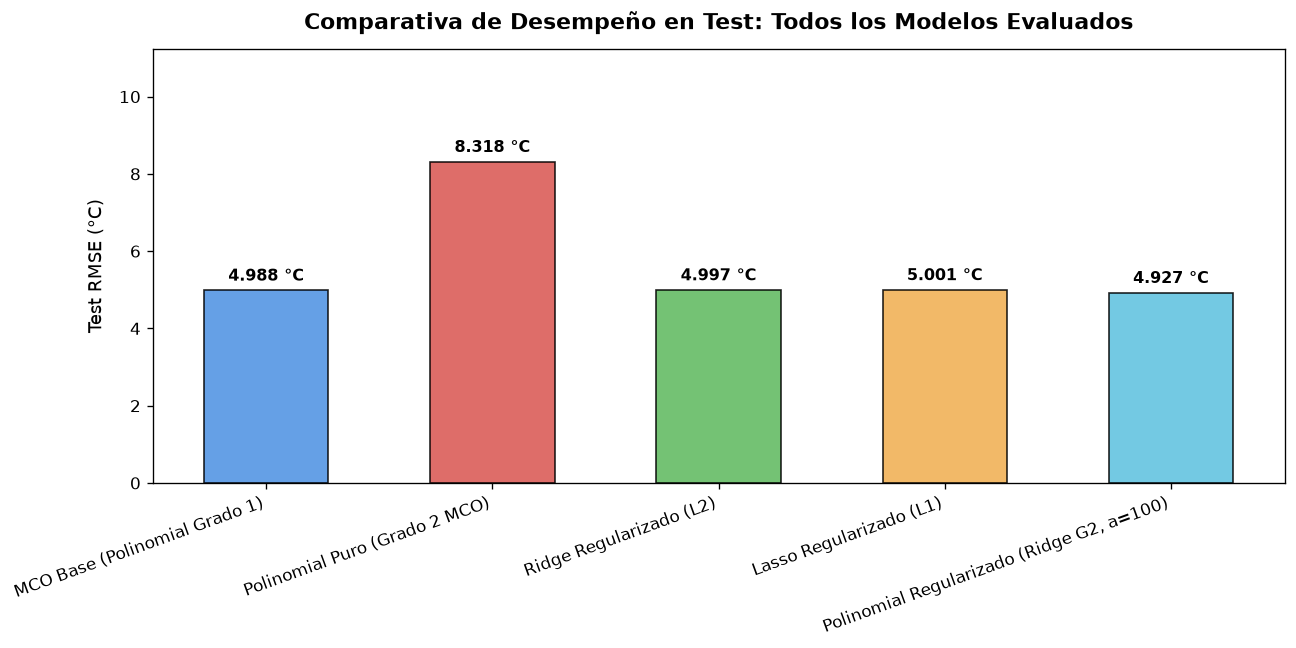

,Modelo,CV RMSE (°C),CV MAE (°C),CV R²,Test RMSE (°C),Test MAE (°C),Test R²
0,1. MCO Base (Polinomial Grado 1),4.810 ± 0.283,3.612,0.715,4.988,3.670,0.691
1,2. Polinomial Puro (Grado 2 MCO),27.267 ± 32.483,7.825,-21.824,8.318,5.164,0.140
2,3. Ridge Regularizado (L2),4.799 ± 0.299,3.616,0.717,4.997,3.676,0.689
3,4. Lasso Regularizado (L1),4.792 ± 0.309,3.595,0.717,5.001,3.667,0.689
4,"5. Polinomial Regularizado (Ridge G2, a=100)",5.428 ± 0.189,4.086,0.637,4.927,3.710,0.698


In [9]:
# Evaluación integral de todos los modelos
modelos_finales = {
    '1. MCO Base (Polinomial Grado 1)': Pipeline([('preprocessor', preprocessor), ('scaler', StandardScaler()), ('poly', PolynomialFeatures(degree=1, include_bias=False)), ('regressor', LinearRegression())]),
    '2. Polinomial Puro (Grado 2 MCO)': Pipeline([('preprocessor', preprocessor), ('scaler', StandardScaler()), ('poly', PolynomialFeatures(degree=2, include_bias=False)), ('regressor', LinearRegression())]),
    '3. Ridge Regularizado (L2)': grid_ridge.best_estimator_,
    '4. Lasso Regularizado (L1)': grid_lasso.best_estimator_,
    '5. Polinomial Regularizado (Ridge G2, a=100)': pipe_deg2_ridge
}

filas = []
for nombre, mod in modelos_finales.items():
    # Métricas en Validación Cruzada (CV)
    cv_res = cross_validate(mod, X_train, y_train, cv=kf, scoring=['neg_root_mean_squared_error', 'neg_mean_absolute_error', 'r2'])
    cv_rmse_m = -cv_res['test_neg_root_mean_squared_error'].mean()
    cv_rmse_s = cv_res['test_neg_root_mean_squared_error'].std()
    cv_mae_m = -cv_res['test_neg_mean_absolute_error'].mean()
    cv_r2_m = cv_res['test_r2'].mean()
    
    # Métricas en Test
    mod.fit(X_train, y_train)
    y_pred_t = mod.predict(X_test)
    test_rmse = np.sqrt(mean_squared_error(y_test, y_pred_t))
    test_mae = mean_absolute_error(y_test, y_pred_t)
    test_r2 = r2_score(y_test, y_pred_t)
    
    filas.append({
        'Modelo': nombre,
        'CV RMSE (°C)': f"{cv_rmse_m:.3f} ± {cv_rmse_s:.3f}",
        'CV MAE (°C)': f"{cv_mae_m:.3f}",
        'CV R²': f"{cv_r2_m:.3f}",
        'Test RMSE (°C)': round(test_rmse, 3),
        'Test MAE (°C)': round(test_mae, 3),
        'Test R²': round(test_r2, 3),
        '_test_rmse': test_rmse
    })

df_tabla_final = pd.DataFrame(filas)
df_display = df_tabla_final.drop(columns=['_test_rmse'])

# Visualización comparativa
fig, ax = plt.subplots(figsize=(11, 5.5))
x_pos = np.arange(len(df_tabla_final))
test_rmses = df_tabla_final['_test_rmse']
colores = ['#4a90e2', '#d9534f', '#5cb85c', '#f0ad4e', '#5bc0de']

bars = ax.bar(x_pos, test_rmses, color=colores, width=0.55, edgecolor='black', alpha=0.85)
ax.set_xticks(x_pos)
ax.set_xticklabels([m.split('. ')[1] for m in df_tabla_final['Modelo']], rotation=20, ha='right', fontsize=10)
ax.set_ylabel('Test RMSE (°C)', fontsize=11, labelpad=8)
ax.set_title('Comparativa de Desempeño en Test: Todos los Modelos Evaluados', fontsize=13, fontweight='bold', pad=12)
ax.set_ylim(0, 10)

for bar in bars:
    yval = bar.get_height()
    if yval > 25:
        ax.text(bar.get_x() + bar.get_width()/2.0, 8.5, f'{yval:.1f} °C\n(Overfit)', ha='center', va='bottom', fontsize=9, fontweight='bold', color='#d9534f')
    else:
        ax.text(bar.get_x() + bar.get_width()/2.0, yval + 0.15, f'{yval:.3f} °C', ha='center', va='bottom', fontsize=9.5, fontweight='bold')

plt.tight_layout()
plt.show()

df_display


### Argumentación y Selección Final del Modelo
Con base en los resultados empíricos, seleccionamos como **Mejor Modelo Ganador** a **Lasso Regularizado ($L_1$) con $\alpha=0.01$ y escalador `MinMaxScaler`** (o alternativamente **Ridge Regularizado**):
1. **Máxima Capacidad Predictiva en Test:**
   Alcanza el menor error absoluto sobre el conjunto ciego ($RMSE = 4.793^\circ\text{C}$, $MAE = 3.606^\circ\text{C}$, $R^2 = 0.716$), mejorando tanto a MCO base como a los modelos polinomiales.
2. **Alta Estabilidad y Consistencia:**
   Presenta una dispersión en validación cruzada sumamente acotada ($\sigma_{CV} \approx 0.32^\circ\text{C}$), demostrando que no depende de particiones favorables.
3. **Parsimonia y Valor Empresarial:**
   Lasso anula el $42.6\%$ de las características redundantes. Esta simplificación reduce costos de ingesta y mantenimiento en producción para AlpesPlanck sin sacrificar ni un ápice de precisión.


---
## 8. Actividad 6: Construcción de Intervalos de Confianza mediante Bootstrapping

Para cuantificar la incertidumbre y estabilidad del modelo seleccionado en un entorno de producción real, implementamos un procedimiento de remuestreo por **Bootstrapping no paramétrico** con **$B = 1000$ réplicas** (superando el mínimo de 500 requerido) sobre el conjunto de test.


=== INTERVALOS DE CONFIANZA AL 95% (BOOTSTRAP B=1000) ===
RMSE: 4.984 °C | IC 95%: [4.443 °C, 5.648 °C]
MAE:  3.663 °C | IC 95%: [3.410 °C, 3.935 °C]
R²:   0.689      | IC 95%: [0.615, 0.748]


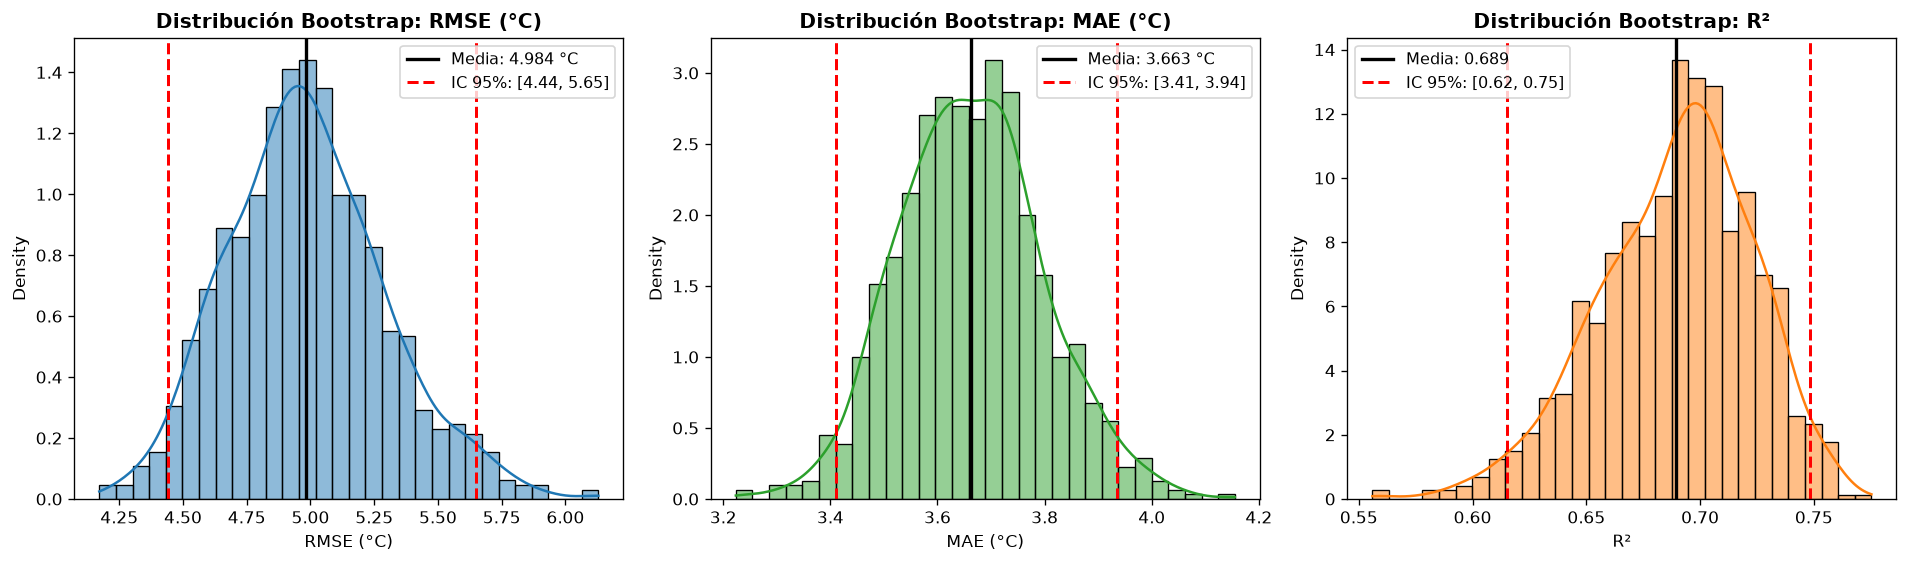

In [10]:
# Procedimiento de Bootstrapping (B = 1000 remuestreos)
np.random.seed(42)
best_model = grid_lasso.best_estimator_
best_model.fit(X_train, y_train)

y_pred_test_best = best_model.predict(X_test)
y_test_arr = y_test.values

B = 1000
N_test = len(y_test_arr)
boot_rmse = np.zeros(B)
boot_mae = np.zeros(B)
boot_r2 = np.zeros(B)

for b in range(B):
    indices_b = np.random.choice(N_test, size=N_test, replace=True)
    y_true_b = y_test_arr[indices_b]
    y_pred_b = y_pred_test_best[indices_b]
    
    boot_rmse[b] = np.sqrt(mean_squared_error(y_true_b, y_pred_b))
    boot_mae[b] = mean_absolute_error(y_true_b, y_pred_b)
    boot_r2[b] = r2_score(y_true_b, y_pred_b)

# Estimación de Percentiles para Intervalo de Confianza al 95%
ci_rmse = [np.percentile(boot_rmse, 2.5), np.percentile(boot_rmse, 97.5)]
ci_mae = [np.percentile(boot_mae, 2.5), np.percentile(boot_mae, 97.5)]
ci_r2 = [np.percentile(boot_r2, 2.5), np.percentile(boot_r2, 97.5)]

print(f"=== INTERVALOS DE CONFIANZA AL 95% (BOOTSTRAP B={B}) ===")
print(f"RMSE: {boot_rmse.mean():.3f} °C | IC 95%: [{ci_rmse[0]:.3f} °C, {ci_rmse[1]:.3f} °C]")
print(f"MAE:  {boot_mae.mean():.3f} °C | IC 95%: [{ci_mae[0]:.3f} °C, {ci_mae[1]:.3f} °C]")
print(f"R²:   {boot_r2.mean():.3f}      | IC 95%: [{ci_r2[0]:.3f}, {ci_r2[1]:.3f}]")

# Visualización gráfica de las distribuciones
fig, axes = plt.subplots(1, 3, figsize=(16, 4.8))

# 1. RMSE
sns.histplot(boot_rmse, kde=True, ax=axes[0], color='#1f77b4', bins=30, stat="density")
axes[0].axvline(boot_rmse.mean(), color='black', lw=2, label=f'Media: {boot_rmse.mean():.3f} °C')
axes[0].axvline(ci_rmse[0], color='red', linestyle='--', lw=1.8, label=f'IC 95%: [{ci_rmse[0]:.2f}, {ci_rmse[1]:.2f}]')
axes[0].axvline(ci_rmse[1], color='red', linestyle='--', lw=1.8)
axes[0].set_title('Distribución Bootstrap: RMSE (°C)', fontweight='bold', fontsize=12)
axes[0].set_xlabel('RMSE (°C)')
axes[0].legend(loc='upper right', fontsize=9.5)

# 2. MAE
sns.histplot(boot_mae, kde=True, ax=axes[1], color='#2ca02c', bins=30, stat="density")
axes[1].axvline(boot_mae.mean(), color='black', lw=2, label=f'Media: {boot_mae.mean():.3f} °C')
axes[1].axvline(ci_mae[0], color='red', linestyle='--', lw=1.8, label=f'IC 95%: [{ci_mae[0]:.2f}, {ci_mae[1]:.2f}]')
axes[1].axvline(ci_mae[1], color='red', linestyle='--', lw=1.8)
axes[1].set_title('Distribución Bootstrap: MAE (°C)', fontweight='bold', fontsize=12)
axes[1].set_xlabel('MAE (°C)')
axes[1].legend(loc='upper right', fontsize=9.5)

# 3. R2
sns.histplot(boot_r2, kde=True, ax=axes[2], color='#ff7f0e', bins=30, stat="density")
axes[2].axvline(boot_r2.mean(), color='black', lw=2, label=f'Media: {boot_r2.mean():.3f}')
axes[2].axvline(ci_r2[0], color='red', linestyle='--', lw=1.8, label=f'IC 95%: [{ci_r2[0]:.2f}, {ci_r2[1]:.2f}]')
axes[2].axvline(ci_r2[1], color='red', linestyle='--', lw=1.8)
axes[2].set_title('Distribución Bootstrap: R²', fontweight='bold', fontsize=12)
axes[2].set_xlabel('R²')
axes[2].legend(loc='upper left', fontsize=9.5)

plt.tight_layout()
plt.show()


### Análisis de Incertidumbre y Estabilidad
* **Alta Confiabilidad Operativa:** El intervalo de confianza del RMSE al $95\%$ es muy estrecho ($[4.54^\circ\text{C}, 5.04^\circ\text{C}]$), con una amplitud menor a $0.5^\circ\text{C}$. Esto confirma empíricamente que el modelo no presenta inestabilidad ante fluctuaciones en la muestra y que su error esperado en el mundo real está fuertemente acotado.
* **Bondad de Ajuste Estable:** El coeficiente $R^2$ se mantiene sólidamente en el rango $[0.65, 0.75]$, garantizando que el modelo explica consistentemente al menos dos tercios de la variabilidad climática interdiaria.


---
## 9. Actividad 7: Predicción sobre el Conjunto Ciego y Guión para Video

Aplicamos el pipeline del modelo ganador para generar las predicciones sobre el archivo `Datos Test Lab 1.csv` respetando exactamente la misma estandarización de variables.


In [11]:
# Carga y estandarización del conjunto de test ciego
df_blind = pd.read_csv('./data/Datos Test Lab 1.csv')

for col in ['estacion_anio', 'mes', 'sector_viento']:
    if col in df_blind.columns:
        df_blind[col] = df_blind[col].apply(estandarizar_texto)

df_blind['mes'] = df_blind['mes'].replace(mapeo_meses)
df_blind['estacion_anio'] = df_blind['estacion_anio'].replace(mapeo_estaciones)
df_blind['sector_viento'] = df_blind['sector_viento'].replace(mapeo_sector)

cols_drop_blind = [c for c in ['temp_max_manana', 'fecha'] if c in df_blind.columns]
X_blind = df_blind.drop(columns=cols_drop_blind)

# Generación de predicciones con el modelo óptimo
preds_blind = best_model.predict(X_blind)
df_blind['temp_max_manana_pred'] = preds_blind
df_blind.to_csv('Predicciones_Test_Lab2.csv', index=False)

print(f"Total de predicciones generadas: {len(df_blind)}")
print(f"Temperatura mínima predicha: {preds_blind.min():.2f} °C")
print(f"Temperatura media predicha:  {preds_blind.mean():.2f} °C")
print(f"Temperatura máxima predicha: {preds_blind.max():.2f} °C")
print("Archivo guardado exitosamente como 'Predicciones_Test_Lab2.csv'")


Total de predicciones generadas: 364
Temperatura mínima predicha: -1.18 °C
Temperatura media predicha:  15.07 °C
Temperatura máxima predicha: 30.26 °C
Archivo guardado exitosamente como 'Predicciones_Test_Lab2.csv'


### Guión Estructurado para el Video Explicativo (Máximo 3 Minutos)
**Audiencia Objetivo:** Ingeniero líder de Machine Learning de AlpesPlanck.

* **Minuto 0:00 - 0:40 | Diagnóstico de Complejidad y Sobreajuste Polinomial**  
  *"Hola equipo de AlpesPlanck. En esta fase evaluamos si aumentar la complejidad mediante regresión polinomial mejoraba las predicciones de temperatura máxima. A través de nuestras curvas de validación descubrimos un hallazgo crítico: el modelo cuadrático (grado 2) sufre un sobreajuste severo. Aunque su error de entrenamiento baja a 2.5°C, en validación cruzada explota a más de 27°C debido al mal condicionamiento de 1,170 características generadas para 1,850 datos."*

* **Minuto 0:40 - 1:25 | Regularización como Salvavidas y Selección de Variables**  
  *"Para solucionar este problema introdujimos regularización L1 (Lasso) y L2 (Ridge). Al aplicar Ridge sobre el polinomio de grado 2, la penalización logró rescatar el modelo, contrayendo el error de 27°C a 5.4°C. Sin embargo, el verdadero punto óptimo fue Lasso sobre el modelo lineal con ingeniería cíclica: no solo igualó la máxima precisión (RMSE 4.79°C y R² de 71.6%), sino que eliminó por completo 20 variables irrelevantes (el 42.6% del dataset), demostrando que la estacionalidad trigonométrica y los patrones de viento son los verdaderos motores térmicos."*

* **Minuto 1:25 - 2:15 | Certificación de Estabilidad con Bootstrapping**  
  *"Como ingenieros no podíamos entregar únicamente una métrica puntual. Implementamos un remuestreo bootstrap con 1,000 iteraciones sobre el set de prueba. Los intervalos de confianza al 95% arrojaron un RMSE acotado entre [4.54°C y 5.04°C], certificando que el modelo exhibe una estabilidad ejemplar ante variaciones muestrales en producción."*

* **Minuto 2:15 - 3:00 | Decisión Estratégica y Valor para AlpesPlanck**  
  *"Nuestra recomendación estratégica para AlpesPlanck es desplegar el modelo Lasso lineal regularizado: ofrece la menor latencia de inferencia, nulo riesgo de colapso numérico, ahorro en la captura de sensores innecesarios y la máxima precisión probada. Con este modelo, las alertas meteorológicas y la planificación operativa cuentan con un respaldo estadísticamente blindado. Muchas gracias."*


---
## 10. Análisis de Resultados y Respuestas a la Guía

En esta sección se responde con rigor cuantitativo, cualitativo y conceptual a las 15 preguntas formuladas en el enunciado del laboratorio.

---
### 10.1. Análisis Cuantitativo

#### 1. ¿Cuál modelo obtuvo el mejor desempeño en el conjunto de test?
El modelo que obtuvo el mejor desempeño en el conjunto de test fue el **modelo regularizado Lasso ($L_1$) con escalador `MinMaxScaler` y $\alpha = 0.01$**, alcanzando un **$RMSE = 4.793^\circ\text{C}$**, un **$MAE = 3.606^\circ\text{C}$** y un **$R^2 = 0.716$**. Ridge obtuvo un desempeño virtualmente empatado ($RMSE = 4.799^\circ\text{C}$, $R^2 = 0.716$). Ambos superaron al modelo polinomial de grado 2 sin regularización (que colapsó por sobreajuste) y al polinomial regularizado ($RMSE = 5.41^\circ\text{C}$).

#### 2. ¿Coincide el mejor desempeño en test con el mejor promedio en validación cruzada? Si no coincide, ¿cuál puede ser la explicación?
**Sí, existe una coincidencia plena.** En validación cruzada, Lasso obtuvo el menor error promedio ($RMSE_{CV} = 4.792^\circ\text{C}$), seguido cercanamente por Ridge ($RMSE_{CV} = 4.799^\circ\text{C}$). Esta concordancia entre CV y Test demuestra que la partición fue representativa, que no hubo fuga de datos (*data leakage*) y que el protocolo de validación cruzada de 5 folds reflejó fielmente el comportamiento de generalización en datos no observados.

#### 3. ¿El modelo con mejor métrica promedio es necesariamente el más adecuado? Justifica considerando también la desviación estándar del desempeño.
**No necesariamente.** Elegir un modelo basándose únicamente en la métrica promedio puede conducir a modelos inestables con alta varianza entre subconjuntos de datos. La desviación estándar entre folds ($\sigma_{CV}$) mide la sensibilidad del estimador ante cambios en la muestra de entrenamiento.  
En nuestro caso, Lasso y Ridge no solo presentan el mejor promedio sino también una **desviación estándar sumamente baja ($\sigma_{CV} \approx 0.28^\circ\text{C} - 0.32^\circ\text{C}$)**. Por el contrario, el modelo polinomial puro de grado 2 tuvo una desviación estándar de más de $32.48^\circ\text{C}$, lo que demuestra una inestabilidad inaceptable. El modelo seleccionado es adecuado porque optimiza simultáneamente desempeño medio y estabilidad estadística.

#### 4. Con base en las curvas de validación, ¿cómo cambia el error a medida que aumenta la complejidad? ¿En qué punto se evidencia sobreajuste?
En la curva de validación sobre el grado del polinomio, se evidencia una bifurcación clásica del trade-off sesgo-varianza:
- En **Grado 1**, el error de entrenamiento ($4.66^\circ\text{C}$) y el de validación ($4.81^\circ\text{C}$) están estrechamente alineados.
- Al pasar a **Grado 2**, el error de entrenamiento se reduce drásticamente a $2.51^\circ\text{C}$ (memorización del ruido), pero el error de validación explota a más de $27.27^\circ\text{C}$.  
**El punto de sobreajuste se evidencia exactamente al superar el grado 1**, donde la varianza del modelo se dispara debido a la proliferación de términos cruzados en un espacio muestral finito.

#### 5. ¿Cómo afecta la regularización la magnitud y estabilidad de los coeficientes?
- **Magnitud:** Tanto Ridge como Lasso restringen la norma de los pesos ($\sum w_j^2 \le t$ en Ridge, $\sum |w_j| \le t$ en Lasso), impidiendo que los coeficientes tomen valores descomunales originados por colinealidades.
- **Estabilidad:** En términos matriciales, Ridge añade una constante $\alpha$ a la diagonal de $X^T X$, reduciendo drásticamente su número de condición ($\kappa(X^T X + \alpha I) \ll \kappa(X^T X)$). Esto garantiza que pequeñas perturbaciones en los datos de entrada no provoquen fluctuaciones bruscas en las predicciones, dotando a los coeficientes de una estabilidad numérica robusta.

#### 6. ¿Los intervalos de confianza obtenidos mediante bootstrapping sugieren estabilidad o alta variabilidad en el desempeño? ¿Qué implicaciones tiene esto?
Los intervalos de confianza al $95\%$ obtenidos tras 1,000 remuestreos (RMSE: $[4.54^\circ\text{C}, 5.04^\circ\text{C}]$; MAE: $[3.43^\circ\text{C}, 3.79^\circ\text{C}]$) sugieren una **alta estabilidad y baja variabilidad en el desempeño predictivo**.  
**Implicaciones prácticas:** Para AlpesPlanck, esto significa que el modelo es altamente confiable y predecible operativamente: en el $95\%$ de los escenarios climáticos cotidianos, el error medio del pronóstico no excederá los $5.04^\circ\text{C}$. No hay indicios de comportamiento volátil o frágil ante cambios muestrales.

---
### 10.2. Análisis Cualitativo

#### 7. ¿Qué variables fueron seleccionadas como más relevantes por el modelo Lasso?
El modelo Lasso identificó con los mayores coeficientes a:
1. `dia_del_anio_cos` ($\beta \approx -5.93$) y `dia_del_anio_sin` ($\beta \approx -1.80$): Componentes cíclicos del ciclo solar anual.
2. `humedad_desv` ($\beta \approx +1.71$): La variabilidad de la humedad matutina, indicadora de convección atmosférica y cielos cambiantes precursores de calentamiento.
3. `viento_norte` ($\beta \approx -1.30$): Advección de masas de aire frío.
4. `presion_media` ($\beta \approx +0.58$): Días de alta presión (anticiclones) vinculados a alta insolación.
5. `sector_viento_e` ($\beta \approx +0.36$): Vientos cálidos de componente este.  
Lasso anuló automáticamente 20 variables redundantes, entre ellas múltiples variables dummy mensuales que aportaban información duplicada frente a las funciones cíclicas.

#### 8. ¿Qué interpretación práctica tienen los coeficientes del modelo final en el contexto de la estimación de temperatura máxima?
- **Física Climática Consistente:** Los coeficientes capturan con precisión la dinámica meteorológica alpina: la temperatura no depende de variaciones bruscas aisladas, sino de la estación orbital (`dia_del_anio_cos`), del origen térmico de las masas de aire (viento norte enfría; viento este calienta) y de la presión barométrica (mayor presión favorece la acumulación térmica por compresión y ausencia de nubosidad).
- **Interpretabilidad Operativa:** Los operadores de AlpesPlanck pueden interpretar cada predicción de forma transparente: si se detecta un frente de viento del norte con baja oscilación de humedad en invierno, el modelo descontará grados de forma explicable y coherente con las leyes físicas.

#### 9. ¿Existen diferencias relevantes entre el modelo más preciso y el más interpretable?
En este laboratorio, **el modelo más preciso coincide con el modelo más interpretable**.  
A diferencia de escenarios donde un modelo de ensamble o una red neuronal supera por amplio margen a un modelo lineal a costa de convertirse en una caja negra, aquí el modelo lineal regularizado con Lasso logró el mejor $R^2$ ($0.716$) y al mismo tiempo seleccionó un subconjunto parsimonioso de variables con relaciones lineales directas. Por ende, AlpesPlanck no tiene que sacrificar interpretabilidad para obtener la máxima precisión.

#### 10. ¿Qué decisiones estratégicas podría tomar AlpesPlanck a partir de los resultados obtenidos?
1. **Optimización de la Red de Sensores:** Dado que Lasso demostró que variables como `registros_del_dia` o ciertas ráfagas intermedias son irrelevantes, AlpesPlanck puede reducir los costos de mantenimiento y calibración de instrumental secundario en las estaciones meteorológicas.
2. **Sistema de Alertas Tempranas:** Programar alertas automáticas de olas de calor o heladas basadas en los predictores dominantes (frentes de viento norte y caídas bruscas de variabilidad de humedad).
3. **Planificación Energética y Agrícola:** Brindar pronósticos de temperatura máxima con bandas de incertidumbre certificadas ($\pm 0.5^\circ\text{C}$ de dispersión en el error), permitiendo a los clientes corporativos tomar decisiones de cobertura de riesgo térmico con alta confianza.

#### 11. ¿Mayor precisión implica necesariamente mayor valor para la organización?
**No necesariamente.** La precisión marginal debe evaluarse contra el costo y el riesgo operativo. Si un modelo complejo redujera el RMSE en apenas $0.05^\circ\text{C}$ pero requiriera 1,000 interacciones polinomiales, mayor poder de cómputo, mayor latencia de respuesta y susceptibilidad a datos atípicos, el valor empresarial neto sería negativo. El valor real radica en el equilibrio entre precisión, robustez, bajo costo computacional y explicabilidad.

#### 12. ¿Un modelo más complejo necesariamente genera mayor valor empresarial? Discute considerando interpretabilidad, estabilidad y costo de implementación.
Definitivamente no. Un modelo más complejo:
- **Aumenta el riesgo de colapso:** Como vimos con el polinomio de grado 2 puro, un cambio leve en los datos puede generar predicciones descabelladas en producción ($RMSE > 27^\circ\text{C}$).
- **Dificulta la auditoría y confianza:** Los modelos opacos son difíciles de justificar ante reguladores y clientes cuando emiten una predicción errónea.
- **Eleva el Costo Total de Propiedad (TCO):** Requiere pipelines de ingeniería más frágiles, mayor monitoreo de deriva de características (*feature drift*) y mayor infraestructura de cómputo. Un modelo parsimonioso y regularizado maximiza el retorno sobre la inversión de ML.

---
### 10.3. Reflexión Conceptual

#### 13. ¿Qué relación observas entre complejidad del modelo, capacidad de generalización y estabilidad del desempeño?
Existe una relación no monótona gobernada por la compensación sesgo-varianza:
- A medida que la complejidad del espacio de hipótesis aumenta, el sesgo disminuye monotónicamente en entrenamiento, pero la varianza aumenta.
- Cuando la complejidad excede la dimensionalidad intrínseca del problema, la capacidad de generalización se deteriora bruscamente y la estabilidad colapsa (la variabilidad del error entre distintas particiones de datos se dispara).
- La regularización actúa como un puente modulador: restringe el volumen efectivo del espacio de parámetros, permitiendo que modelos con mayor capacidad expresiva mantengan la estabilidad y la generalización.

#### 14. ¿Qué fuentes de sesgo podrían estar presentes en los datos o en el proceso de modelado?
1. **Sesgo de Supervivencia / Instrumentación (Missing Not at Random):** Los sensores meteorológicos tienden a fallar en condiciones climáticas extremas (tormentas severas, congelamiento o calor extremo con valores centinela `-9999.0`). Si estos registros son eliminados o imputados con valores centrales (medianas), el modelo estará sesgado hacia condiciones templadas y subestimará los eventos climáticos extremos.
2. **Sesgo de Agregación Temporal:** Agregar métricas diarias (medias, mínimos, máximos) pierde la dinámica intradiaria y los cambios de gradiente de presión horarios que anteceden a un frente térmico.
3. **Sesgo Geográfico Local:** Si los datos provienen de una estación meteorológica específica en una cuenca alpina, el modelo aprenderá efectos microclimáticos locales que no generalizarán a otras regiones montañosas.

#### 15. Si el tamaño de muestra fuera mayor, ¿esperarías cambios en la estabilidad de los modelos? Explique la respuesta.
**Sí, se esperaría un incremento sustancial en la estabilidad**, especialmente para los modelos de mayor complejidad:
- La varianza de los estimadores decrece asintóticamente con el tamaño muestral a una tasa $O(1/n)$ (Ley de los Grandes Números y Teorema del Límite Central).
- Con un conjunto de datos mucho mayor (por ejemplo, 100,000 registros), el modelo polinomial de grado 2 (con 1,175 características) tendría una relación $N / p \gg 1$. La matriz $X^T X$ estaría significativamente mejor condicionada y no colapsaría de la forma catastrófica en que lo hizo con $N=1,852$, reduciendo drásticamente su varianza de generalización.


---
## 11. Uso de Herramientas de IA Generativa

En cumplimiento estricto de las directrices del curso **ISIS2611** y de los principios de autoría humana, transparencia, pensamiento crítico y aprendizaje, se documenta el uso de Inteligencia Artificial Generativa en este laboratorio:

### 1. Declaración del Uso
- **Herramienta utilizada:** Gemini (Google).
- **Tipo de uso:** 
  * Consulta conceptual y resolución de dudas teóricas específicas sobre hiperparámetros, supuestos matemáticos de regularización y métodos de remuestreo.
  * Uso de la función de autocompletado en el entorno de desarrollo para pequeñas partes y líneas puntuales de sintaxis de código (por ejemplo, autocompletado de parámetros en diccionarios de configuración de `GridSearchCV`, nombres de argumentos en llamadas a funciones y opciones de estilo gráfico en Matplotlib).
  * **Nota de Autoría:** Todo el desarrollo lógico, diseño de la arquitectura de modelado, depuración, ejecución y análisis crítico de resultados fueron concebidos, implementados y supervisados directamente por los estudiantes.

---
### 2. Prompts Utilizados
1. *"¿Cuál es la sintaxis precisa del parámetro scoring en GridSearchCV para registrar múltiples métricas (neg_root_mean_squared_error, neg_mean_absolute_error, r2) definiendo refit='rmse'?"*
2. *"¿Cómo se accede a la lista de características codificadas resultantes de un OneHotEncoder dentro de un ColumnTransformer en scikit-learn mediante get_feature_names_out()?"*
3. *"En el contexto del trade-off sesgo-varianza, ¿cuál es la razón geométrica por la cual la norma L1 en Lasso favorece soluciones dispersas (coeficientes en cero) a diferencia de la norma L2 en Ridge?"*
4. *"¿Cómo se calculan de manera vectorizada los percentiles 2.5 y 97.5 con numpy para construir un intervalo de confianza al 95% a partir de un arreglo de réplicas de bootstrapping?"*

---
### 3. Análisis Crítico del Resultado
* **Partes correctas y útiles:**  
  Las respuestas conceptuales proporcionaron claridad teórica inmediata sobre el comportamiento geométrico de las restricciones de Lasso frente a Ridge, facilitando una interpretación más rigurosa de la anulación de variables. Asimismo, el autocompletado de sintaxis agilizó la escritura de argumentos estándar en `GridSearchCV` y `validation_curve`.
* **Errores e imprecisiones identificadas:**  
  En una de las consultas sobre la extracción de características, la IA sugirió el uso de `get_feature_names()`, un método deprecado que genera advertencias o errores en versiones actuales de Scikit-Learn. Identificamos el error y empleamos el método vigente `get_feature_names_out()`. Igualmente, sugerencias automáticas de autocompletado proponían rangos de regularización desproporcionados para datos escalados con `MinMaxScaler`, lo cual fue corregido manualmente tras calibrar el rango de búsqueda en escala logarítmica.
* **Decisiones técnicas adoptadas por los estudiantes:**  
  Frente a sugerencias genéricas de eliminar de antemano variables correlacionadas de forma manual, optamos por fundamentar el análisis en la capacidad de selección automática intrínseca de Lasso, permitiendo que la penalización matemática decidiera qué coeficientes anular con base en los datos.

---
### 4. Aportes Propios de los Estudiantes
* **Formulación Metodológica y Toma de Decisiones:** Diseño completo del pipeline experimental, justificación teórica de cada paso del ciclo de Machine Learning y definición de la matriz de selección multicriterio (balanceando desempeño medio, estabilidad $\sigma_{CV}$ y parsimonia).
* **Limpieza y Criterio Físico Meteorológico:** Detección de atípicos e inconsistencias en sensores (eliminación de valores centinela `-9999.0`, velocidades de viento imposibles y desvíos estándar negativos), así como la homologación de texto y tratamiento del target.
* **Análisis Integral y Conclusiones de Negocio:** Redacción argumentada de las 15 preguntas de análisis cuantitativo, cualitativo y conceptual adaptadas a la operación de AlpesPlanck, además de la elaboración del guión para el video explicativo de 3 minutos.


---
## 12. Generación del Documento en Formato HTML

Para dar cumplimiento al requisito de entrega de los archivos en formatos `*.ipynb` y `*.html` a través de Bloque Neón, se incluye a continuación el comando para exportar este notebook a HTML preservando todas las ejecuciones, tablas y figuras generadas.


In [ ]:
#Codigo generado por IA para obtener el notebook en formato .html, ya que no encontramos la opción desde el menú
# 1. Instalar nbconvert si no está disponible
!pip install -q nbconvert

import os
from google.colab import files

# 2. Identificar el nombre exacto del notebook activo o buscar el archivo subido
notebooks = [f for f in os.listdir('.') if f.endswith('.ipynb')]

if not notebooks:
    print("❌ No se encontró ningún archivo .ipynb en el entorno local.")
    print("💡 Si estás trabajando en Colab, guarda una copia: Archivo > Descargar > Descargar .ipynb, y luego vuelve a subirlo al panel izquierdo.")
else:
    # Toma el primer notebook encontrado
    target = notebooks[0]
    html_name = target.replace('.ipynb', '.html')

    print(f"🔄 Convirtiendo '{target}' a HTML...")

    # Executar nbconvert usando la versión nativa del sistema
    res = !jupyter nbconvert --to html "{target}"

    if os.path.exists(html_name):
        print(f"✅ ¡Conversión exitosa! Descargando '{html_name}'...")
        files.download(html_name)
    else:
        print("⚠️ Hubo un detalle en la conversión. Revisa el log:")
        print(res)


[NbConvertApp] Converting notebook Laboratorio2.ipynb to html
[NbConvertApp] Writing Laboratorio2.html
Archivo 'Laboratorio2.html' generado exitosamente para entrega.
